# 06 — Feature selection

Whether attribution-guided selection improves accuracy, and whose attribution should
guide it.

| Strategy | Features kept |
|---|---|
| all | every feature from notebook 03 |
| own top-k | the model's own k highest permutation importances |
| stratified | best two of the target's own history, best one of every other family |
| Ridge top-k | Ridge's k highest permutation importances, given to every model |

k equals the size of the stratified set, so the three selection rules keep the same
number of features. Rankings use the training-period importances of notebook 05; the
noise probe is never eligible. Each configuration is scored on the test period over
20 seeds and compared with the noise floor.

Input: `data/processed/features_*.csv`, `results/04_best_params.json`,
`results/05_importance.csv` · Output: `results/06_selection.csv`

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

BRANCHES = ["original", "seasonal", "trend"]
MODEL_NAMES = ["XGBoost", "RandomForest", "Ridge"]
SEEDS = range(20)

BASE = {"XGBoost": XGBRegressor(n_jobs=1),
        "RandomForest": RandomForestRegressor(n_jobs=-1),
        "Ridge": make_pipeline(StandardScaler(), Ridge())}
params = json.load(open("../results/04_best_params.json"))
importance = pd.read_csv("../results/05_importance.csv",
                         index_col=["branch", "model", "feature"])["importance"]


def make_model(b, name, seed):
    est = clone(BASE[name]).set_params(**params[f"{b}|{name}"])
    if name != "Ridge":
        est.set_params(random_state=seed)
    return est


def family(f):
    if f.startswith("LST"):
        return "LST"
    if f.startswith("SPEI"):
        return "drought"
    if f.startswith("month"):
        return "calendar"
    return "own history"


data = {}
for b in BRANCHES:
    df = pd.read_csv(f"../data/processed/features_{b}.csv", index_col="date", parse_dates=True)
    X, y, train = df.drop(columns=["target", "split"]), df["target"], df["split"] == "train"
    data[b] = (X[train], X[~train], y[train], y[~train])

## Selected features

In [2]:
def ranked(b, name):
    s = importance[b][name].drop("noise_probe")
    return list(s.sort_values(ascending=False).index)


def stratified(b, name):
    order = ranked(b, name)
    keep = [f for f in order if family(f) == "own history"][:2]
    for fam in ["calendar", "drought", "LST"]:
        keep += [f for f in order if family(f) == fam][:1]
    return keep


selections = {}
for b in BRANCHES:
    all_cols = list(data[b][0].columns)
    for name in MODEL_NAMES:
        strat = stratified(b, name)
        k = len(strat)
        selections[(b, name)] = {"all": all_cols,
                                 "own top-k": ranked(b, name)[:k],
                                 "stratified": strat,
                                 "Ridge top-k": ranked(b, "Ridge")[:k]}

short = lambda cols: ", ".join(c.replace("NDVI_", "").replace("NDVI", "") for c in cols)
for b in BRANCHES:
    print(f"\n{b}")
    for name in MODEL_NAMES:
        for strategy in ["own top-k", "stratified", "Ridge top-k"]:
            if name == "Ridge" and strategy == "Ridge top-k":
                continue
            print(f"  {name:12s} {strategy:11s} {short(selections[(b, name)][strategy])}")


original
  XGBoost      own top-k   LST_lag1, lag1, lag24, lag11, lag23
  XGBoost      stratified  lag1, lag24, month_cos, SPEI_6_lag1, LST_lag1
  XGBoost      Ridge top-k lag1, lag24, lag12, LST_lag1, lag3
  RandomForest own top-k   LST_lag1, lag24, lag1, lag12, lag18
  RandomForest stratified  lag24, lag1, month_cos, SPEI_6_lag1, LST_lag1
  RandomForest Ridge top-k lag1, lag24, lag12, LST_lag1, lag3
  Ridge        own top-k   lag1, lag24, lag12, LST_lag1, lag3
  Ridge        stratified  lag1, lag24, month_cos, SPEI_6_lag1, LST_lag1

seasonal
  XGBoost      own top-k   LST_S_lag1, S_lag24, S_lag1, S_lag12, S_lag23
  XGBoost      stratified  S_lag24, S_lag1, month_cos, SPEI_6_S_lag2, LST_S_lag1
  XGBoost      Ridge top-k S_lag1, S_lag24, LST_S_lag1, S_lag12, S_lag14
  RandomForest own top-k   LST_S_lag1, S_lag24, S_lag1, S_lag12, S_lag18
  RandomForest stratified  S_lag24, S_lag1, month_cos, SPEI_6_S_lag2, LST_S_lag1
  RandomForest Ridge top-k S_lag1, S_lag24, LST_S_lag1, S_lag12, S_l

## Test-period accuracy

In [3]:
rows = []
for b in BRANCHES:
    Xtr, Xte, ytr, yte = data[b]
    for name in MODEL_NAMES:
        seeds = [0] if name == "Ridge" else SEEDS
        for strategy, cols in selections[(b, name)].items():
            if name == "Ridge" and strategy == "Ridge top-k":
                continue
            r2 = [r2_score(yte, make_model(b, name, s).fit(Xtr[cols], ytr).predict(Xte[cols]))
                  for s in seeds]
            rows.append(dict(branch=b, model=name, strategy=strategy, k=len(cols),
                             R2_mean=np.mean(r2), R2_sd=np.std(r2)))

results = pd.DataFrame(rows)
base = results[results.strategy == "all"].set_index(["branch", "model"])
results["delta"] = results.apply(
    lambda r: r.R2_mean - base.loc[(r.branch, r.model), "R2_mean"], axis=1)
results["floor"] = results.apply(
    lambda r: max(r.R2_sd, base.loc[(r.branch, r.model), "R2_sd"]), axis=1)
results["beyond_floor"] = (results.delta.abs() > 2 * results.floor) & (results.floor > 0) \
                          | ((results.floor == 0) & (results.delta.abs() > 0.005))

for b in BRANCHES:
    t = results[results.branch == b].pivot(index="strategy", columns="model", values="delta")
    t = t.loc[["own top-k", "stratified", "Ridge top-k"], MODEL_NAMES]
    print(f"\n{b}: change in test R2 against all features "
          f"(all: " + ", ".join(f"{m} {base.loc[(b, m), 'R2_mean']:.4f}" for m in MODEL_NAMES) + ")")
    print(t.round(4).to_string())


original: change in test R2 against all features (all: XGBoost 0.8778, RandomForest 0.8633, Ridge 0.8619)
model        XGBoost  RandomForest   Ridge
strategy                                  
own top-k    -0.0058       -0.0046 -0.0104
stratified   -0.0026        0.0155 -0.0195
Ridge top-k   0.0078        0.0050     NaN

seasonal: change in test R2 against all features (all: XGBoost 0.8731, RandomForest 0.8722, Ridge 0.8324)
model        XGBoost  RandomForest   Ridge
strategy                                  
own top-k     0.0110       -0.0151 -0.0138
stratified   -0.0185        0.0027 -0.0052
Ridge top-k  -0.0148       -0.0111     NaN

trend: change in test R2 against all features (all: XGBoost 0.8655, RandomForest 0.9127, Ridge 0.9932)
model        XGBoost  RandomForest   Ridge
strategy                                  
own top-k    -0.0183       -0.0085  0.0002
stratified   -0.1238       -0.0085 -0.0018
Ridge top-k  -0.0184        0.0061     NaN


A difference is counted as real only when it exceeds twice the larger seed-to-seed
standard deviation of the two configurations. Ridge is deterministic, so for Ridge a
threshold of 0.005 is used.

In [4]:
print(results[["branch", "model", "strategy", "k", "R2_mean", "R2_sd", "delta", "beyond_floor"]]
      .round(4).to_string(index=False))

  branch        model    strategy  k  R2_mean  R2_sd   delta  beyond_floor
original      XGBoost         all 12   0.8778 0.0023  0.0000         False
original      XGBoost   own top-k  5   0.8721 0.0018 -0.0058          True
original      XGBoost  stratified  5   0.8752 0.0022 -0.0026         False
original      XGBoost Ridge top-k  5   0.8856 0.0017  0.0078          True
original RandomForest         all 12   0.8633 0.0020  0.0000         False
original RandomForest   own top-k  5   0.8587 0.0018 -0.0046          True
original RandomForest  stratified  5   0.8788 0.0018  0.0155          True
original RandomForest Ridge top-k  5   0.8683 0.0020  0.0050          True
original        Ridge         all 12   0.8619 0.0000  0.0000         False
original        Ridge   own top-k  5   0.8515 0.0000 -0.0104          True
original        Ridge  stratified  5   0.8424 0.0000 -0.0195          True
seasonal      XGBoost         all 14   0.8731 0.0171  0.0000         False
seasonal      XGBoost   o

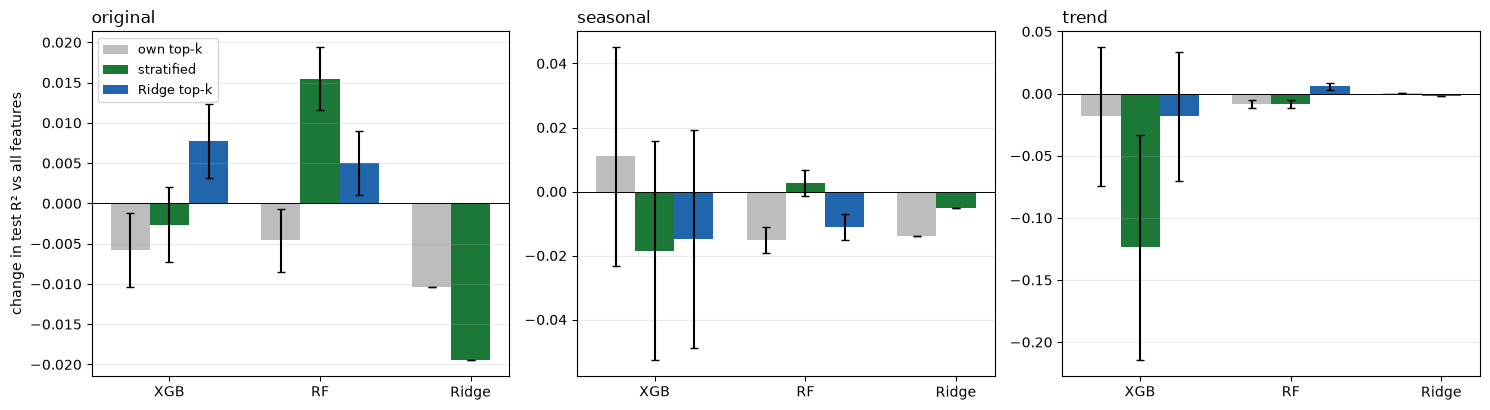

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=False)
strategies = ["own top-k", "stratified", "Ridge top-k"]
colors = {"own top-k": "#bdbdbd", "stratified": "#1b7837", "Ridge top-k": "#2166ac"}
for ax, b in zip(axes, BRANCHES):
    sub = results[(results.branch == b) & (results.strategy != "all")]
    for i, strategy in enumerate(strategies):
        s = sub[sub.strategy == strategy].set_index("model").reindex(MODEL_NAMES)
        x = np.arange(3) + (i - 1) * 0.26
        ax.bar(x, s.delta, width=0.26, color=colors[strategy], label=strategy,
               yerr=2 * s.floor, capsize=3)
    ax.axhline(0, color="black", lw=0.7)
    ax.set_xticks(range(3), ["XGB", "RF", "Ridge"])
    ax.set_title(b, loc="left")
    ax.grid(alpha=0.25, axis="y")
axes[0].set_ylabel("change in test R² vs all features")
axes[0].legend(fontsize=9)
fig.tight_layout()
fig.savefig("../figures/06_selection.png", dpi=150, bbox_inches="tight")
plt.show()

## Saving

In [6]:
results.to_csv("../results/06_selection.csv", index=False)
json.dump({f"{b}|{m}": sel for (b, m), sel in selections.items()},
          open("../results/06_selected_features.json", "w"), indent=2)
print("saved")

saved
